In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

folder_path = Path(r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1-2. [Lead] Triboresistive sensor\1. [Lead] DC TRS\1. 실험자료\260811_contact DC3 직렬연결\3. 직렬 연결")

save_summary = False
output_filename = "Average_summary.csv"


Found 9 CSV files.
Processed: 3._no.1-2.csv | Average = 0.693206
Processed: 3._no.1.csv | Average = 0.430449
Processed: 3._no.2.csv | Average = 0.477235
Processed: 3._no.3-4.csv | Average = 0.817924
Processed: 3._no.3.csv | Average = 0.634605
Processed: 3._no.4.csv | Average = 0.372074
Processed: 3._no.5-6.csv | Average = 0.975870
Processed: 3._no.5.csv | Average = 0.593587
Processed: 3._no.6.csv | Average = 0.807734
----------------------------------------


,File Name,Average Value,Data Count,Max Value,Min Value
0,3._no.1-2.csv,0.693206,10000,0.705938,0.678906
1,3._no.1.csv,0.430449,10000,0.448438,0.412813
2,3._no.2.csv,0.477235,10000,0.496406,0.460938
3,3._no.3-4.csv,0.817924,10000,0.835000,0.801094
4,3._no.3.csv,0.634605,10000,0.650469,0.622969
5,3._no.4.csv,0.372074,10000,0.385781,0.358438
6,3._no.5-6.csv,0.975870,10000,0.994531,0.957500
7,3._no.5.csv,0.593587,10000,0.608125,0.581094
8,3._no.6.csv,0.807734,10000,0.824531,0.793750


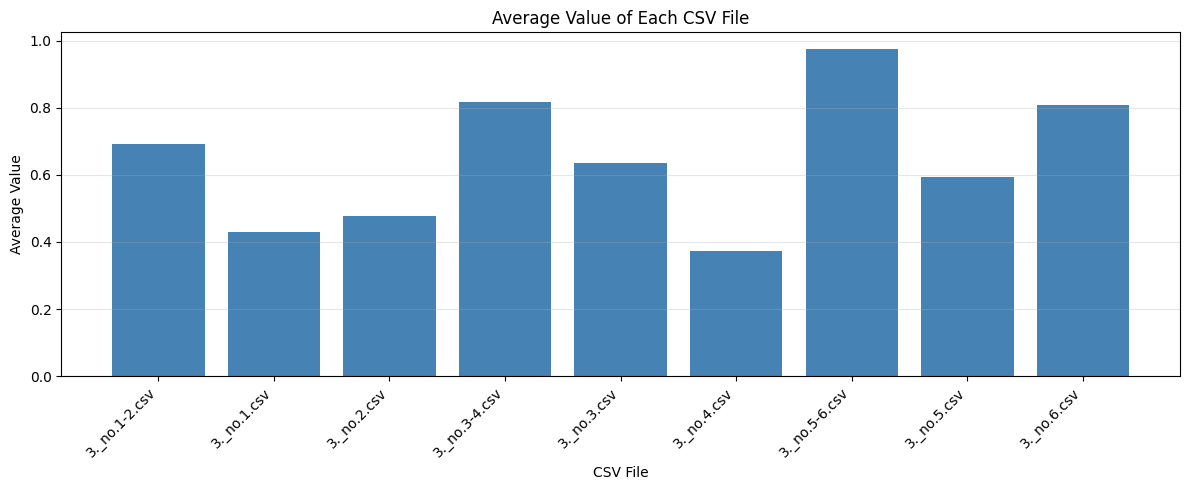

In [6]:
csv_files = sorted(folder_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files were found in: {folder_path}")

results = []

print(f"Found {len(csv_files)} CSV files.")

for csv_file in csv_files:
    df = pd.read_csv(csv_file, header=None, usecols=[0, 1])
    df.columns = ["Time", "Value"]

    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    df = df.dropna(subset=["Time", "Value"]).reset_index(drop=True)

    if df.empty:
        print(f"Skipped {csv_file.name}: no valid numeric data.")
        continue

    average_value = df["Value"].mean()
    value_count = len(df)

    results.append({
        "File Name": csv_file.name,
        "Average Value": average_value,
        "Data Count": value_count,
        "Max Value": df["Value"].max(),
        "Min Value": df["Value"].min()
    })

    print(f"Processed: {csv_file.name} | Average = {average_value:.6f}")

summary_df = pd.DataFrame(results)

if summary_df.empty:
    raise ValueError("No valid CSV data was processed.")

summary_df = summary_df.sort_values("File Name").reset_index(drop=True)
summary_df = summary_df.round({
    "Average Value": 6,
    "Max Value": 6,
    "Min Value": 6
})

print("-" * 40)
display(summary_df)

if save_summary:
    output_path = folder_path / output_filename
    summary_df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Summary saved to: {output_path}")


plt.figure(figsize=(12, 5))
plt.bar(summary_df["File Name"], summary_df["Average Value"], color="steelblue")
plt.xlabel("CSV File")
plt.ylabel("Average Value")
plt.title("Average Value of Each CSV File")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
